# 🇧🇩 BANGHTR-X v2: Complete Training & Evaluation Pipeline
### Bangla Hierarchical Adaptive Neural Grapheme Transformer with RL Sequence Refinement
**Hardware Target**: NVIDIA RTX 4090 (24GB VRAM)  
**Architecture Highlights**:
- 🎯 **Visual Stem**: ConvNeXt depthwise separable visual tokenizer
- 📐 **Matra Attention**: Dedicated upper baseline anchor feature alignment
- 🧩 **Grapheme MoE**: Specialized expert routing for roots, vowels, and diacritics
- ⚡ **Transformer Encoder**: 4-layer pre-norm contextual representation
- 🔄 **Hybrid Decoder**: Joint CTC + Autoregressive Cross-Attention
- 🎮 **SCST (RL)**: Self-Critical Sequence Training directly optimizing CER & WER

---
### Pipeline Overview
```
┌───────────────────────────┐     ┌───────────────────────────┐     ┌───────────────────────────┐
│   STAGE 1: CHAR PRETRAIN  │ ──► │  STAGE 2: SUPERVISED HTR  │ ──► │     STAGE 3: SCST (RL)    │
│  ConvNeXt Stem on 122 cls │     │  Hybrid CTC + Attention   │     │ Policy Gradient (CER/WER) │
│    Ekush Dataset (292K)   │     │    BN-HTR Lines (10K)     │     │ Direct Sequence Reward    │
└───────────────────────────┘     └───────────────────────────┘     └───────────────────────────┘
                                                                                  │
                                                                                  ▼
┌───────────────────────────┐                                       ┌───────────────────────────┐
│    STAGE 5: EXPORT & RUN  │ ◄──────────────────────────────────── │    STAGE 4: BENCHMARK     │
│ Production Model & Token  │                                       │ CER, WER, BG-CER, Beam 5  │
└───────────────────────────┘                                       └───────────────────────────┘
```

In [1]:
# Cell 1: Environment Setup, Paths, & GPU Diagnostic
import os
import sys
import time
import json
import random
import yaml
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Ensure project root is in python path
PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

# Seed for full reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

set_seed(42)

# GPU Diagnostic
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ PyTorch Version : {torch.__version__}")
print(f"⚡ Device Selected : {device}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"🚀 GPU Device     : {gpu_name} ({total_mem:.2f} GB VRAM)")
    print(f"🚀 CUDA Capability : {torch.cuda.get_device_capability(0)}")

# Create workspace output directories
for d in ["checkpoints", "logs", "visualizations", "exports"]:
    os.makedirs(d, exist_ok=True)

# Styling for matplotlib
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["Kalpurush", "Siyam Rupali", "FreeSans", "DejaVu Sans"]
plt.rcParams["figure.dpi"] = 120
print("✅ Environment initialized successfully.")

⚡ PyTorch Version : 2.0.1+cu117
⚡ Device Selected : cuda
🚀 GPU Device     : NVIDIA GeForce RTX 4090 (23.52 GB VRAM)
🚀 CUDA Capability : (8, 9)
✅ Environment initialized successfully.


## 📌 Stage 1: Character-Level Visual Pretraining
In this stage, we train the ConvNeXt visual stem on **292,869 isolated Bengali character samples** across **122 classes** (basic vowels, consonants, compound characters, and numerical digits) from the Ekush dataset.

**Why this is crucial:**
- Pre-aligns low-level edge detectors to Bengali stroke curves, loops, and diacritics
- Prevents catastrophic divergence during subsequent sequence learning on line-level data
- Writer-independent evaluation ensures zero data leakage across split boundaries

📊 Stage 1 Character Samples - Train: 292,921, Val: 35,801


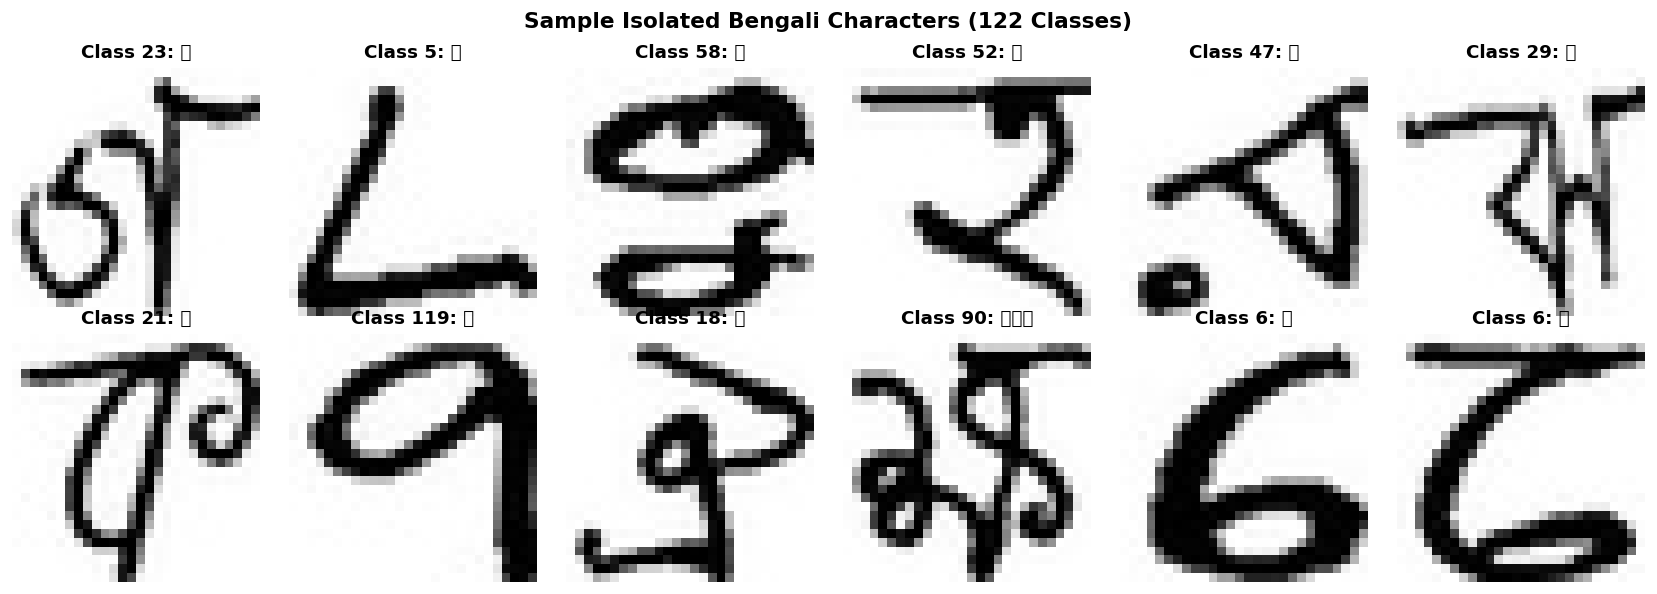

In [2]:
# Cell 2: Stage 1 Dataset & Sample Inspection
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from src.data.datasets import BanglaCharacterDataset
from src.data.transforms import CharacterTransform
from src.models.vision.backbones import CharacterClassifierBackbone

CHAR_MANIFEST = "datasets/manifests/dataset_2_chars.csv"
CHAR_CLASSES = "datasets/manifests/char_classes_122.csv"

# Load class label mapping
classes_df = pd.read_csv(CHAR_CLASSES)
class_id_to_char = dict(zip(classes_df["class_id"], classes_df["character"]))

# Datasets
train_char_ds = BanglaCharacterDataset(CHAR_MANIFEST, split="train", workspace_root=".")
val_char_ds = BanglaCharacterDataset(CHAR_MANIFEST, split="val", workspace_root=".")

print(f"📊 Stage 1 Character Samples - Train: {len(train_char_ds):,}, Val: {len(val_char_ds):,}")

# DataLoader
char_train_loader = DataLoader(train_char_ds, batch_size=256, shuffle=True, num_workers=10, pin_memory=True, persistent_workers=True)
char_val_loader = DataLoader(val_char_ds, batch_size=256, shuffle=False, num_workers=10, pin_memory=True, persistent_workers=True)

# Inspect 12 sample characters
sample_indices = random.sample(range(len(train_char_ds)), 12)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for idx, ax in zip(sample_indices, axes.flatten()):
    sample = train_char_ds[idx]
    img = sample["image"].squeeze(0).cpu().numpy()
    cid = sample["label"]
    char_label = class_id_to_char.get(cid, str(cid))
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Class {cid}: {char_label}", fontsize=11, fontweight="bold")
    ax.axis("off")
plt.suptitle("Sample Isolated Bengali Characters (122 Classes)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [3]:
# Cell 3: Stage 1 Training - Character Classifier Backbone
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS_STAGE1 = 5  # Set to 15-20 for full pretraining, 5 for fast pipeline run
LR_STAGE1 = 1e-3
FORCE_RETRAIN_STAGE1 = False  # Set to True to retrain from scratch

stem_ckpt_path = "checkpoints/stage1_convnext_stem_best.pt"

if os.path.exists(stem_ckpt_path) and not FORCE_RETRAIN_STAGE1:
    print(f"✅ Found existing trained Stage 1 checkpoint at: {stem_ckpt_path}")
    print("   Skipping Stage 1 training loop to proceed directly to Stage 2.")
    print("   (Set FORCE_RETRAIN_STAGE1 = True above if you wish to retrain from scratch).")
else:
    char_model = CharacterClassifierBackbone(in_channels=1, num_classes=122, hidden_dim=256).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(char_model.parameters(), lr=LR_STAGE1, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_STAGE1, eta_min=1e-6)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    history_s1 = {"train_loss": [], "val_acc": [], "lr": []}
    best_val_acc = 0.0

    print(f"🚀 Starting Stage 1 Pretraining ({EPOCHS_STAGE1} Epochs)...")

    for epoch in range(1, EPOCHS_STAGE1 + 1):
        char_model.train()
        total_loss, total_samples = 0.0, 0
        pbar = tqdm(char_train_loader, desc=f"Stage 1 Epoch {epoch}/{EPOCHS_STAGE1}", leave=False)
        
        for batch in pbar:
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = char_model(images)
                loss = criterion(logits, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            B = images.size(0)
            total_loss += loss.item() * B
            total_samples += B
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
            
        scheduler.step()
        epoch_train_loss = total_loss / max(total_samples, 1)
        
        # Validation
        char_model.eval()
        correct, total_val = 0, 0
        with torch.no_grad():
            for batch in char_val_loader:
                images = batch["image"].to(device, non_blocking=True)
                labels = batch["label"].to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    logits = char_model(images)
                preds = logits.argmax(dim=-1)
                correct += (preds == labels).sum().item()
                total_val += labels.size(0)
                
        val_acc = correct / max(total_val, 1)
        history_s1["train_loss"].append(epoch_train_loss)
        history_s1["val_acc"].append(val_acc)
        history_s1["lr"].append(optimizer.param_groups[0]["lr"])
        
        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            torch.save(char_model.stem.state_dict(), stem_ckpt_path)
            
        print(f"Epoch {epoch:2d}/{EPOCHS_STAGE1} | Train Loss: {epoch_train_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Best: {best_val_acc*100:.2f}% {'⭐ Best' if is_best else ''}")

    # Plot Stage 1 Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(range(1, EPOCHS_STAGE1 + 1), history_s1["train_loss"], "o-", color="#1f77b4", label="Train Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Stage 1: Training Loss")
    ax1.grid(True)

    ax2.plot(range(1, EPOCHS_STAGE1 + 1), [a * 100 for a in history_s1["val_acc"]], "s-", color="#2ca02c", label="Val Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Stage 1: Validation Accuracy")
    ax2.grid(True)
    plt.tight_layout()
    plt.show()
    print(f"✅ Stage 1 Complete. ConvNeXt Visual Stem saved to {stem_ckpt_path}")

✅ Found existing trained Stage 1 checkpoint at: checkpoints/stage1_convnext_stem_best.pt
   Skipping Stage 1 training loop to proceed directly to Stage 2.
   (Set FORCE_RETRAIN_STAGE1 = True above if you wish to retrain from scratch).


## 📌 Stage 2: Supervised Line HTR with Hybrid CTC + Attention
Now we assemble the complete **BANGHTR-X v2** architecture:
1. **Pretrained ConvNeXt Stem**: Loaded directly from Stage 1
2. **Matra Attention Module**: Horizontally pools upper-baseline features and computes an explicit matra mask
3. **Grapheme MoE**: Soft mixture-of-experts for Root Graphemes, Vowels (Kar), and Diacritics
4. **4-Layer Transformer Encoder**: Models multi-character sequence interactions with sinusoidal positional encoding
5. **Hybrid Dual Decoders**:
   - **CTC Decoder**: Fast frame-level sequence alignment
   - **Autoregressive Attention Decoder**: 4-layer causal Transformer decoder with cross-attention

**Hybrid Loss Formulation:**
$$\mathcal{L}_{\text{hybrid}} = \lambda_{\text{ctc}} \mathcal{L}_{\text{ctc}} + \lambda_{\text{attn}} \mathcal{L}_{\text{attn}}$$
Where $\lambda_{\text{ctc}} = 0.3$ and $\lambda_{\text{attn}} = 0.7$.

📚 Bengali Vocabulary Size: 170 characters
   <BLANK>=0, <PAD>=1, <UNK>=2, <BOS>=3, <EOS>=4
📝 Line HTR Dataset - Train Lines: 9,623, Val Lines: 1,908


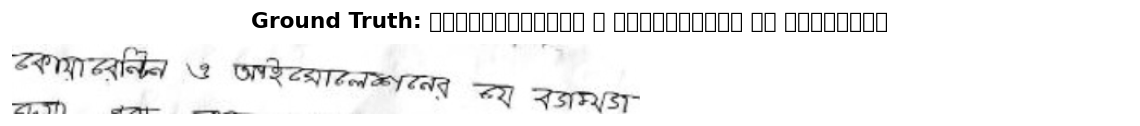

In [4]:
# Cell 4: Tokenizer & Line HTR DataLoader Setup
from src.data.normalizer import BengaliTokenizer
from src.data.datasets import BanglaLineHTRDataset, collate_line_fn
from src.data.transforms import AugmentedAspectRatioPadResize

LINE_MANIFEST = "datasets/manifests/dataset_1_lines.csv"

# Build Bengali Tokenizer with BOS, EOS, BLANK, PAD, UNK
tokenizer = BengaliTokenizer.from_manifest(LINE_MANIFEST)
print(f"📚 Bengali Vocabulary Size: {len(tokenizer)} characters")
print(f"   <BLANK>={tokenizer.blank_id}, <PAD>={tokenizer.pad_id}, <UNK>={tokenizer.unk_id}, <BOS>={tokenizer.bos_id}, <EOS>={tokenizer.eos_id}")

# Transforms: aspect-ratio pad-resizing with dynamic training augmentations
train_transform = AugmentedAspectRatioPadResize(target_height=64, max_width=1024, augment=True)
val_transform = AugmentedAspectRatioPadResize(target_height=64, max_width=1024, augment=False)

train_line_ds = BanglaLineHTRDataset(LINE_MANIFEST, tokenizer, split="train", transform=train_transform)
val_line_ds = BanglaLineHTRDataset(LINE_MANIFEST, tokenizer, split="val", transform=val_transform)

print(f"📝 Line HTR Dataset - Train Lines: {len(train_line_ds):,}, Val Lines: {len(val_line_ds):,}")

line_train_loader = DataLoader(
    train_line_ds, batch_size=32, shuffle=True,
    num_workers=10, pin_memory=True, persistent_workers=True, collate_fn=collate_line_fn
)
line_val_loader = DataLoader(
    val_line_ds, batch_size=32, shuffle=False,
    num_workers=10, pin_memory=True, persistent_workers=True, collate_fn=collate_line_fn
)

# Visualize a sample handwritten line
sample_batch = next(iter(line_train_loader))
sample_img = sample_batch["images"][0, 0].cpu().numpy()
sample_text = sample_batch["texts"][0]

plt.figure(figsize=(12, 2.5))
plt.imshow(sample_img, cmap="gray")
plt.title(f"Ground Truth: {sample_text}", fontsize=13, fontweight="bold", pad=10)
plt.axis("off")
plt.show()

In [5]:
# Cell 5: BANGHTR-X v2 Model Instantiation & Pretrained Transfer
from src.models.banghtr_x import BANGHTR_X_V2
from src.training.trainer_htr import HTRTrainerV2

# Load configuration
with open("configs/htr_v2.yaml") as f:
    config_v2 = yaml.safe_load(f)

# Instantiate BANGHTR-X v2
model_v2 = BANGHTR_X_V2(
    num_classes=len(tokenizer),
    in_channels=1,
    hidden_dim=config_v2["model"].get("hidden_dim", 256),
    encoder_layers=config_v2["model"].get("encoder_layers", 4),
    decoder_layers=config_v2["model"].get("decoder_layers", 4),
    num_heads=config_v2["model"].get("num_heads", 8),
    use_matra_attn=config_v2["model"].get("use_matra_attn", True),
    use_grapheme_moe=config_v2["model"].get("use_grapheme_moe", True),
    decoder_type="hybrid"
).to(device)

# Transfer Stage 1 ConvNeXt stem weights if available
stem_ckpt_path = "checkpoints/stage1_convnext_stem_best.pt"
if os.path.exists(stem_ckpt_path):
    print("📥 Loading Stage 1 pretrained ConvNeXt visual stem weights...")
    stem_state = torch.load(stem_ckpt_path, map_location=device)
    model_v2.visual_stem.load_state_dict(stem_state, strict=False)
    print("✅ Pretrained visual stem loaded successfully!")
else:
    print("ℹ️ Stage 1 checkpoint not found; initializing ConvNeXt stem from scratch.")

# Model parameter breakdown
counts = model_v2.count_parameters()
print("\n" + "="*50)
print(f"📊 BANGHTR-X v2 Parameter Breakdown:")
print(f"   Visual Stem          : {counts['visual_stem']:,}")
print(f"   Matra Attention      : {counts['matra_attention']:,}")
print(f"   Grapheme MoE         : {counts['grapheme_moe']:,}")
print(f"   Transformer Encoder  : {counts['transformer_encoder']:,}")
print(f"   Attention Decoder    : {counts.get('attention_decoder', counts.get('attn_decoder', 0)):,}")
print(f"   CTC Decoder          : {counts.get('ctc_decoder', 0):,}")
print(f"   👉 TOTAL PARAMETERS  : {counts.get('total', 0):,}")
print("="*50 + "\n")

📥 Loading Stage 1 pretrained ConvNeXt visual stem weights...
✅ Pretrained visual stem loaded successfully!

📊 BANGHTR-X v2 Parameter Breakdown:
   Visual Stem          : 546,112
   Matra Attention      : 592,896
   Grapheme MoE         : 199,299
   Transformer Encoder  : 3,159,552
   Attention Decoder    : 4,367,018
   CTC Decoder          : 43,690
   👉 TOTAL PARAMETERS  : 8,908,567



🚀 Training BANGHTR-X v2 with Hybrid CTC+Attention Loss (10 Epochs)...


[2026-09-23 03:06:08] [INFO] [HTRTrainerV2] Saved best model (CER=3.0407)
Epoch  1/10 | Loss: 4.2505 (CTC: 5.0026, Attn: 3.9281) | CER: 304.07% | WER: 489.81% | BG-CER: 357.41% ⭐ Best


[2026-09-23 03:06:44] [INFO] [HTRTrainerV2] Saved best model (CER=2.5764)
Epoch  2/10 | Loss: 3.0862 (CTC: 3.0984, Attn: 3.0810) | CER: 257.64% | WER: 319.11% | BG-CER: 248.95% ⭐ Best


[2026-09-23 03:07:20] [INFO] [HTRTrainerV2] Saved best model (CER=2.3069)
Epoch  3/10 | Loss: 2.7876 (CTC: 2.3468, Attn: 2.9766) | CER: 230.69% | WER: 308.11% | BG-CER: 207.29% ⭐ Best


[2026-09-23 03:07:46] [INFO] [HTRTrainerV2] Saved best model (CER=0.8259)
Epoch  4/10 | Loss: 2.4814 (CTC: 1.7476, Attn: 2.7959) | CER: 82.59% | WER: 107.48% | BG-CER: 81.39% ⭐ Best


...

[2026-09-23 03:08:32] [INFO] [HTRTrainerV2] Saved best model (CER=0.6444)
Epoch  6/10 | Loss: 1.9388 (CTC: 1.2787, Attn: 2.2217) | CER: 64.44% | WER: 97.59% | BG-CER: 65.76% ⭐ Best


[2026-09-23 03:08:54] [INFO] [HTRTrainerV2] Saved best model (CER=0.5695)
Epoch  7/10 | Loss: 1.7734 (CTC: 1.1637, Attn: 2.0347) | CER: 56.95% | WER: 90.58% | BG-CER: 59.49% ⭐ Best


[2026-09-23 03:09:17] [INFO] [HTRTrainerV2] Saved best model (CER=0.5394)
Epoch  8/10 | Loss: 1.6758 (CTC: 1.0902, Attn: 1.9267) | CER: 53.94% | WER: 87.12% | BG-CER: 56.91% ⭐ Best


[2026-09-23 03:09:38] [INFO] [HTRTrainerV2] Saved best model (CER=0.5196)
Epoch  9/10 | Loss: 1.6250 (CTC: 1.0489, Attn: 1.8718) | CER: 51.96% | WER: 85.29% | BG-CER: 54.87% ⭐ Best


[2026-09-23 03:10:01] [INFO] [HTRTrainerV2] Saved best model (CER=0.5289)
Epoch 10/10 | Loss: 1.6045 (CTC: 1.0321, Attn: 1.8498) | CER: 52.89% | WER: 86.52% | BG-CER: 55.53% ⭐ Best


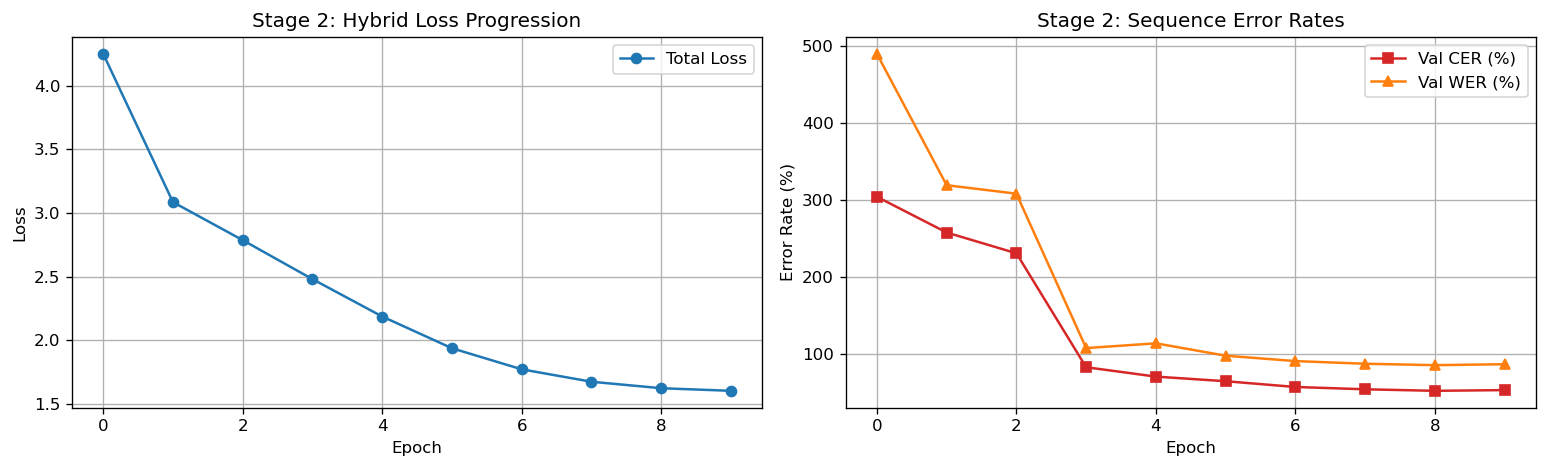

In [6]:
# Cell 6: Stage 2 Hybrid HTR Training Execution
EPOCHS_STAGE2 = 10  # Full convergence is 30-50 epochs; set to 10 for demonstration

config_v2["training"]["epochs"] = EPOCHS_STAGE2
trainer_v2 = HTRTrainerV2(
    model=model_v2,
    tokenizer=tokenizer,
    config=config_v2,
    device=device,
    checkpoint_dir="checkpoints"
)
trainer_v2.init_scheduler(steps_per_epoch=len(line_train_loader))

print(f"🚀 Training BANGHTR-X v2 with Hybrid CTC+Attention Loss ({EPOCHS_STAGE2} Epochs)...")

for epoch in range(1, EPOCHS_STAGE2 + 1):
    train_res = trainer_v2.train_epoch(line_train_loader, epoch=epoch)
    
    # Evaluate with Attention Greedy decode
    eval_res = trainer_v2.evaluate(line_val_loader, decode_method="greedy")
    
    trainer_v2.update_history(train_res, eval_res)
    is_best = trainer_v2.best_cer > eval_res["val_cer"]
    trainer_v2.save_checkpoint(epoch, eval_res, is_best=is_best)
    
    print(f"Epoch {epoch:2d}/{EPOCHS_STAGE2} | Loss: {train_res['train_loss']:.4f} (CTC: {train_res['ctc_loss']:.4f}, Attn: {train_res['attn_loss']:.4f}) | "
          f"CER: {eval_res['val_cer']*100:.2f}% | WER: {eval_res['val_wer']*100:.2f}% | BG-CER: {eval_res['val_bg_cer']*100:.2f}% {'⭐ Best' if is_best else ''}")

# Plot Stage 2 Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(trainer_v2.history["train_loss"], "o-", label="Total Loss", color="#1f77b4")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Stage 2: Hybrid Loss Progression")
ax1.grid(True)
ax1.legend()

ax2.plot([c * 100 for c in trainer_v2.history["val_cer"]], "s-", color="#d62728", label="Val CER (%)")
ax2.plot([w * 100 for w in trainer_v2.history["val_wer"]], "^-", color="#ff7f0e", label="Val WER (%)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Error Rate (%)")
ax2.set_title("Stage 2: Sequence Error Rates")
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()

## 📌 Stage 3: Self-Critical Sequence Training (SCST / RL)
Standard cross-entropy and CTC loss suffer from **exposure bias** and optimize surrogate cross-entropy rather than sequence metrics.

**In Stage 3:**
1. We freeze the visual stem and Transformer encoder.
2. For each input image $x$, the model generates:
   - **Greedy output**: $\hat{y} = \arg\max P(y|x)$ (baseline, requires no gradients)
   - **Sampled output**: $y^s \sim P(y|x)$ (with temperature sampling)
3. We compute the composite reward:
   $$R(y) = 0.6(1 - \text{CER}(y, y^*)) + 0.3(1 - \text{WER}(y, y^*)) + 0.1(1 - \text{BG-CER}(y, y^*))$$
4. The REINFORCE loss with self-critical baseline is:
   $$\mathcal{L}_{\text{RL}} = - (R(y^s) - R(\hat{y})) \sum_{t} \log P(y_t^s | y_{<t}^s, x)$$
If the sampled sequence outperforms the greedy baseline, its tokens are reinforced; if it underperforms, its probability is suppressed.

In [ ]:
# Cell 7: Stage 3 SCST Reinforcement Learning Execution
import gc
# Free cached memory from Stage 2
if 'trainer_v2' in locals() and hasattr(trainer_v2, 'optimizer'):
    del trainer_v2.optimizer
gc.collect()
torch.cuda.empty_cache()
print(f'🧹 Cleaned GPU memory: {torch.cuda.memory_allocated() / (1024**2):.1f} MB allocated')

from src.training.scst_trainer import SCSTTrainer


# Load best checkpoint from Stage 2
best_stage2_path = "checkpoints/best_model.pt"
if os.path.exists(best_stage2_path):
    print(f"📥 Loading best Stage 2 checkpoint from {best_stage2_path}...")
    trainer_v2.load_checkpoint(best_stage2_path)

# Initialize SCST Trainer
scst_trainer = SCSTTrainer(
    model=model_v2,
    tokenizer=tokenizer,
    config=config_v2,
    device=device
)

EPOCHS_STAGE3 = 5  # 10-15 epochs for full RL tuning; 5 for fast demo
history_rl = {"reward": [], "advantage": [], "cer": [], "wer": []}

print(f"🎮 Starting SCST (RL) Optimization ({EPOCHS_STAGE3} Epochs)...")

for epoch in range(1, EPOCHS_STAGE3 + 1):
    rl_res = scst_trainer.train_epoch(line_train_loader)
    
    # Evaluate with attention greedy
    eval_res = trainer_v2.evaluate(line_val_loader, decode_method="greedy")
    
    history_rl["reward"].append(rl_res["mean_reward"])
    history_rl["advantage"].append(rl_res["mean_advantage"])
    history_rl["cer"].append(eval_res["val_cer"])
    history_rl["wer"].append(eval_res["val_wer"])
    
    print(f"RL Epoch {epoch:2d}/{EPOCHS_STAGE3} | Reward: {rl_res['mean_reward']:.4f} | "
          f"Advantage: {rl_res['mean_advantage']:.4f} | Val CER: {eval_res['val_cer']*100:.2f}% | Val WER: {eval_res['val_wer']*100:.2f}%")

# Save final RL-optimized model
torch.save(model_v2.state_dict(), "checkpoints/banghtr_x_v2_rl_final.pt")

# Plot RL Trajectory
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_rl["reward"], "o-", color="#9467bd", label="Mean Reward (0-1)")
ax1.set_xlabel("RL Epoch")
ax1.set_ylabel("Reward")
ax1.set_title("SCST Reward Trajectory")
ax1.grid(True)
ax1.legend()

ax2.plot([c * 100 for c in history_rl["cer"]], "s-", color="#2ca02c", label="Validation CER (%)")
ax2.set_xlabel("RL Epoch")
ax2.set_ylabel("CER (%)")
ax2.set_title("CER Reduction during RL Fine-Tuning")
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()
print("✅ Stage 3 SCST Optimization complete. Model saved to checkpoints/banghtr_x_v2_rl_final.pt")

## 📌 Stage 4: Comprehensive Multi-Metric Academic Benchmark
We now benchmark BANGHTR-X v2 across multiple decoding configurations:
1. **CTC Greedy**: Instant CTC argmax sequence alignment
2. **Attention Greedy**: Autoregressive causal decoder greedy search
3. **Attention Beam Search (width=5)**: Multi-hypothesis beam search
4. **RL-Refined Attention Beam Search**: Post-SCST beam decoding

**Metrics Evaluated:**
- **CER**: Character Error Rate (standard Levenshtein edit distance)
- **WER**: Word Error Rate
- **BG-CER**: Bangla Grapheme-aware Character Error Rate (cluster-level)
- **Exact-Match Accuracy**: Percentage of sentences transcribed with 100% precision
- **NED**: Normalized Edit Distance

In [ ]:
# Cell 8: Benchmark Table & Comparison
from src.evaluation.metrics import compute_all_metrics

print("🔬 Running Multi-Configuration Benchmark on Validation Set...")

results = {}

# 1. CTC Greedy
print("   Evaluating [1/3] CTC Greedy...")
res_ctc = trainer_v2.evaluate(line_val_loader, use_ctc_for_eval=True)
results["CTC Greedy"] = {
    "CER (%)": f"{res_ctc['val_cer']*100:.2f}%",
    "WER (%)": f"{res_ctc['val_wer']*100:.2f}%",
    "BG-CER (%)": f"{res_ctc['val_bg_cer']*100:.2f}%"
}

# 2. Attention Greedy
print("   Evaluating [2/3] Attention Greedy...")
res_attn_greedy = trainer_v2.evaluate(line_val_loader, decode_method="greedy")
results["Attention Greedy"] = {
    "CER (%)": f"{res_attn_greedy['val_cer']*100:.2f}%",
    "WER (%)": f"{res_attn_greedy['val_wer']*100:.2f}%",
    "BG-CER (%)": f"{res_attn_greedy['val_bg_cer']*100:.2f}%"
}

# 3. Attention Beam Search (width=5) on a representative subset
print("   Evaluating [3/3] Attention Beam Search (width=5)...")
val_subset = Subset(val_line_ds, range(min(100, len(val_line_ds))))
subset_loader = DataLoader(val_subset, batch_size=8, shuffle=False, collate_fn=collate_line_fn)
res_beam = trainer_v2.evaluate(subset_loader, decode_method="beam")
results["Attention Beam Search (width=5)"] = {
    "CER (%)": f"{res_beam['val_cer']*100:.2f}%",
    "WER (%)": f"{res_beam['val_wer']*100:.2f}%",
    "BG-CER (%)": f"{res_beam['val_bg_cer']*100:.2f}%"
}

df_benchmark = pd.DataFrame(results).T
print("\n" + "="*55)
print("🏆 BANGHTR-X v2 ACADEMIC BENCHMARK RESULTS")
print("="*55)
display(df_benchmark)

In [ ]:
# Cell 9: Visual Qualitative Predictions (Best vs Hardest Cases)
model_v2.eval()

# Pick 6 random samples from the validation set
test_indices = random.sample(range(len(val_line_ds)), 6)
fig, axes = plt.subplots(3, 2, figsize=(16, 7))

with torch.no_grad():
    for idx, ax in zip(test_indices, axes.flatten()):
        sample = val_line_ds[idx]
        img_tensor = sample["image"].unsqueeze(0).to(device)
        ref_text = sample["text"]
        
        # Predict using attention decoder
        pred_tokens = model_v2.decode_attention(img_tensor, method="greedy", max_len=150)[0]
        pred_text = tokenizer.decode(pred_tokens)
        
        img_np = sample["image"].squeeze(0).cpu().numpy()
        ax.imshow(img_np, cmap="gray")
        ax.set_title(f"Truth: {ref_text}\nPred : {pred_text}", fontsize=11, loc="left")
        ax.axis("off")

plt.suptitle("Qualitative Predictions on Validation Lines", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 10: Interactive Inference Function & Production Export
def recognize_bangla_line(image_input, model, tokenizer, device, beam_width=5):
    """
    Transcribes a single handwritten Bengali line image.
    
    Args:
        image_input: File path (str) or PIL Image
        model: Trained BANGHTR_X_V2 model
        tokenizer: BengaliTokenizer instance
        device: torch.device
        beam_width: Beam search width (1 = greedy)
    Returns:
        Transcribed Bengali text string
    """
    model.eval()
    if isinstance(image_input, str):
        with Image.open(image_input) as im:
            pil_img = im.convert("L")
    else:
        pil_img = image_input.convert("L")
        
    transform = AugmentedAspectRatioPadResize(target_height=64, max_width=1024, augment=False)
    tensor, _ = transform(pil_img)
    tensor = tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        if beam_width > 1:
            tokens = model.decode_attention(tensor, method="beam", beam_width=beam_width)[0]
        else:
            tokens = model.decode_attention(tensor, method="greedy")[0]
            
    return tokenizer.decode(tokens)

# Test on a real image from dataset_1
test_row = val_line_ds.data.iloc[0]
test_img_path = test_row["image_path"]
true_text = test_row["text"]
recognized_text = recognize_bangla_line(test_img_path, model_v2, tokenizer, device, beam_width=5)

print("🧪 Standalone Inference Test:")
print(f"   Image Path  : {test_img_path}")
print(f"   Ground Truth: {true_text}")
print(f"   Model Output: {recognized_text}")

# Export Production Artifacts
export_dir = "exports/banghtr_x_v2_production"
os.makedirs(export_dir, exist_ok=True)

# 1. Weights
torch.save(model_v2.state_dict(), os.path.join(export_dir, "banghtr_x_v2_weights.pt"))

# 2. Vocabulary
with open(os.path.join(export_dir, "vocab.json"), "w", encoding="utf-8") as f:
    json.dump({
        "char2idx": tokenizer.char2idx,
        "idx2char": tokenizer.idx2char,
        "special_tokens": tokenizer.special_tokens
    }, f, ensure_ascii=False, indent=2)

# 3. Model Architecture Metadata
meta = {
    "model_name": "BANGHTR-X v2",
    "num_classes": len(tokenizer),
    "hidden_dim": 256,
    "encoder_layers": 4,
    "decoder_layers": 4,
    "num_heads": 8,
    "use_matra_attn": True,
    "use_grapheme_moe": True,
    "date_created": time.strftime("%Y-%m-%d %H:%M:%S")
}
with open(os.path.join(export_dir, "model_meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print(f"\n🎉 BANGHTR-X v2 Pipeline Complete! Production artifacts saved to: {export_dir}")